<a href="https://colab.research.google.com/github/DKHolder00/AAI590-Capstone-Churn/blob/main/Capstone_Project_Final_Code_Complete_Draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project

# Data Preparation and Initial Exploration
## Overview

This section focuses on data ingestion, inspection, and preprocessing for the two datasets used in this project: a synthetic streaming customer dataset and the IBM Telco customer churn dataset.

The goal of this stage is to prepare both datasets for machine learning modeling by ensuring data quality, correcting data types, handling hidden data issues, and transforming variables into a model-ready format.

Key steps include loading the datasets from Google Drive, inspecting their structure and contents, identifying potential data quality issues, and applying necessary cleaning procedures. Special attention is given to validating data types and addressing hidden inconsistencies, such as improperly formatted numerical values.

This process establishes a clean and reliable foundation for subsequent feature engineering, model development, and evaluation.

### Mounting the content to use from My Google

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Ingestion
###This section loads the two datasets used in the project:
- Synthetic streaming dataset
- IBM Telco churn dataset
### These datasets are used to model customer churn from both behavioral and subscription perspectives, forming the basis of the Customer 360 feature layer.

In [2]:
BASE_PATH = "/content/drive/MyDrive/AAI590Capstone"

In [3]:
STREAM_PATH = f"{BASE_PATH}/data/synthetic_customer_behavior_and_churn.csv"
TELCO_PATH = f"{BASE_PATH}/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [4]:
import pandas as pd
import numpy as np

###1.1 Data Loading

This section loads the two datasets used in the project into pandas DataFrames. The streaming dataset represents customer engagement and behavioral data, while the Telco dataset represents subscription, billing, and service-related information.

The `pandas.read_csv()` function is used to read each dataset from its respective file path stored in Google Drive. These datasets form the foundation of the Customer 360 feature layer, which integrates behavioral and subscription-based features for churn prediction.

After execution, both datasets are successfully loaded into memory as `df_stream` and `df_telco`, enabling further data inspection, preprocessing, and model development.

In [5]:
df_stream = pd.read_csv(STREAM_PATH)
df_telco = pd.read_csv(TELCO_PATH)

## 2. Initial Dataset Inspection

This section displays the dimensions of both datasets using the `.shape` attribute, which returns the number of rows (observations) and columns (features) in each DataFrame.

Understanding dataset size is important for evaluating model complexity, training time, and the potential for generalization.



### 2.1 Dataset Dimension and Structure
The streaming dataset contains 15,000 observations and 21 features, indicating a relatively large and behavior-rich dataset. The Telco dataset contains 7,043 observations and 21 features, representing a smaller but well-structured dataset focused on subscription and billing characteristics.

These dataset sizes are appropriate for machine learning modeling, as they provide sufficient data for training, validation, and testing while maintaining manageable computational requirements.

In [6]:
print("Streaming dataset shape:", df_stream.shape)
print("Telco dataset shape:", df_telco.shape)

Streaming dataset shape: (15000, 21)
Telco dataset shape: (7043, 21)


### 2.2 Streaming Dataset Overview

This section displays the first five rows of the streaming dataset using the `.head()` function. This provides an initial view of the data structure, feature types, and sample values.

The dataset contains a combination of demographic, behavioral, and subscription-related features. Examples include customer age, region, income level, subscription type, monthly and total charges, as well as engagement metrics such as session duration, login frequency, and support ticket activity.

From this preview, it is evident that the dataset captures both customer characteristics and platform usage behavior, which are critical for modeling churn in a streaming environment. Additionally, the presence of the binary `churn` variable confirms that the dataset is suitable for supervised classification tasks.

This initial inspection helps verify that the data has been loaded correctly and provides insight into how different feature groups may contribute to churn prediction.

In [7]:
df_stream.head()

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,...,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,CUST_000001,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,...,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,...,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,...,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,...,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,...,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


### 2.3 Telco Dataset Overview

This section displays the first five rows of the Telco customer churn dataset using the `.head()` function. This provides an initial overview of the dataset’s structure, feature types, and sample values.

The dataset includes a variety of customer attributes related to subscription services, billing, and service usage. These features include demographic indicators (e.g., gender, senior citizen status), account characteristics (e.g., tenure, contract type, payment method), and service-related variables (e.g., internet service, online security, streaming services).

From this preview, it is evident that the dataset captures the subscription and billing side of customer behavior, which complements the engagement-focused features in the streaming dataset. The presence of the `Churn` variable, represented as a categorical value (Yes/No), confirms that the dataset is suitable for supervised classification after appropriate preprocessing.

This inspection step verifies that the dataset has been loaded correctly and provides insight into how subscription structure and service usage may influence customer churn.

In [8]:
df_telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.4 Dataset Structure and Data Types
### 2.4.1 Streaming

This section examines the structure and data types of the streaming dataset using the `.info()` function. This provides a summary of the dataset, including the number of entries, column names, non-null counts, and data types for each feature.

The dataset contains 15,000 observations and 21 variables, with no missing values across any columns. The features consist of a mix of data types, including numerical variables (integers and floats) and categorical variables (objects). Numerical features include tenure, age, session duration, login frequency, and support activity, while categorical features include gender, region, subscription type, and payment method.

The presence of multiple categorical variables indicates that encoding will be required before applying machine learning models. Additionally, the `customer_id` and `signup_date` columns are stored as object types and represent identifiers and temporal data, respectively, which will need to be removed or transformed during preprocessing.

Overall, this step confirms that the dataset is complete, well-structured, and suitable for further preprocessing and modeling, with clear distinctions between feature types that guide the next steps in the machine learning pipeline.

In [9]:
df_stream.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   15000 non-null  object 
 1   signup_date                   15000 non-null  object 
 2   tenure_months                 15000 non-null  int64  
 3   age                           15000 non-null  int64  
 4   gender                        15000 non-null  object 
 5   region                        15000 non-null  object 
 6   income_level                  15000 non-null  object 
 7   subscription_type             15000 non-null  object 
 8   monthly_charges               15000 non-null  float64
 9   total_charges                 15000 non-null  float64
 10  usage_frequency               15000 non-null  object 
 11  avg_session_duration_minutes  15000 non-null  float64
 12  number_of_logins_per_month    15000 non-null  int64  
 13  n

### 2.4 Dataset Structure and Data Types
### 2.4.2 Telco

This section examines the structure and data types of the Telco customer churn dataset using the `.info()` function. This summary provides insight into the number of observations, feature composition, and data types present in the dataset.

The dataset contains 7,043 observations and 21 variables, with no explicitly reported missing values. However, the dataset is composed primarily of categorical variables (object type), alongside a smaller number of numerical features such as tenure, monthly charges, and total charges.

A key observation is that the `TotalCharges` variable is stored as an object data type rather than a numeric type, indicating potential data quality issues such as non-numeric or blank values. This requires further preprocessing to convert the column into a usable numerical format for machine learning models.

Additionally, the `customerID` column serves as a unique identifier and does not contribute predictive value, while the `Churn` variable is represented as a categorical outcome (Yes/No) that must be encoded for classification tasks.

Overall, this step highlights the need for data type correction, categorical encoding, and feature selection, ensuring that the dataset is properly prepared for model training and aligned with the requirements of the machine learning pipeline.

In [10]:
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.5 Missing Values Analysis
### 2.5.1 Streaming Dataset

This section evaluates the presence of missing values in the streaming dataset using the `.isnull().sum()` function, which computes the number of null values in each column.

The results indicate that there are no missing values across any of the 21 variables in the dataset. This confirms that the dataset is complete and does not require imputation or removal of incomplete records.

The absence of missing data simplifies the preprocessing pipeline and reduces the need for data cleaning interventions. As a result, subsequent steps can focus on feature transformation, encoding of categorical variables, and model development without concerns related to data sparsity or bias introduced through imputation.

Overall, this finding supports the reliability and integrity of the dataset, making it well-suited for machine learning modeling and analysis.

In [11]:
df_stream.isnull().sum()

,0
customer_id,0
signup_date,0
tenure_months,0
age,0
gender,0
region,0
income_level,0
subscription_type,0
monthly_charges,0
total_charges,0


### 2.6 Missing Values Analysis
### 2.6.1 Telco Dataset

This section evaluates the presence of missing values in the Telco dataset using the `.isnull().sum()` function, which calculates the number of null entries for each variable.

The output indicates that there are no missing values across any of the columns. However, further inspection of the dataset reveals that this result can be misleading. Specifically, the `TotalCharges` variable is stored as an object data type and may contain blank or non-numeric values that are not recognized as null by pandas.

This highlights an important data quality consideration: missing or invalid data may not always be explicitly represented as null values. As a result, additional preprocessing steps are required to convert the `TotalCharges` column to a numeric format and properly handle any hidden missing values.

This step demonstrates the importance of validating data types and not relying solely on standard missing value checks. Ensuring accurate data representation is critical for building reliable machine learning models and maintaining the integrity of the analysis.

In [12]:
df_telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 3. Data Cleaning and Issue Resolution

This section addresses a data quality issue identified in the Telco dataset. Although the dataset initially appeared to have no missing values, further inspection revealed that the `TotalCharges` column was stored as an object data type and contained non-numeric or blank entries.



### 3.1 Identification of Data Issues (TotalCharges Problem)
To resolve this issue, the `TotalCharges` column was converted to a numeric data type using the `pd.to_numeric()` function with the `errors='coerce'` parameter. This operation forces any non-numeric or improperly formatted values to be converted into null (NaN) values.

Following this conversion, rows containing null values were removed using the `.dropna()` function. This ensures that all remaining records contain valid numerical data for the `TotalCharges` variable.

This step is critical for maintaining data integrity and ensuring compatibility with machine learning models, which require numerical inputs for accurate training. It also highlights the importance of validating data types and identifying hidden data issues that may not be detected through standard missing value checks.

In [13]:
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')
df_telco = df_telco.dropna()

### 3.2 Data Cleaning and Post-Cleaning Structure

This section re-examines the structure and data types of the Telco dataset after applying data cleaning procedures. The `.info()` function is used to confirm that the dataset has been successfully transformed into a consistent and usable format.

Following the conversion of the `TotalCharges` column to a numeric data type and the removal of invalid entries, the dataset now contains 7,032 observations, reduced slightly from the original dataset. This confirms that rows containing non-numeric or missing values have been appropriately handled.

A key improvement is that the `TotalCharges` variable is now correctly represented as a float data type, ensuring it can be used effectively in machine learning models. The dataset continues to include a combination of numerical and categorical features, with most variables remaining in object format and requiring encoding in subsequent preprocessing steps.

This validation step confirms that the dataset is now clean, consistent, and ready for feature transformation and model training. Ensuring correct data types at this stage is essential for maintaining model accuracy and preventing errors during the training process.

In [14]:
df_telco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

## 4. Final Preprocessing
This section completes the preprocessing stage by preparing both datasets for machine learning modeling. Non-predictive identifier variables are removed, the Telco churn target is converted to numeric format, duplicate records are checked, and categorical variables are encoded into numerical representations using one-hot encoding.

A final conversion step is also applied to transform Boolean values (`True`/`False`) into integer format (`1`/`0`), ensuring full compatibility with machine learning algorithms.

These steps ensure that both datasets are fully structured, consistent, and model-ready for train-test splitting and baseline model development.

In [15]:
# =========================================================
# Final Preprocessing Steps
# =========================================================

import pandas as pd

# -----------------------------
# 1. Drop non-predictive ID columns
# -----------------------------
if 'customer_id' in df_stream.columns:
    df_stream = df_stream.drop(columns=['customer_id'])

if 'customerID' in df_telco.columns:
    df_telco = df_telco.drop(columns=['customerID'])

# -----------------------------
# 2. Handle date column in streaming dataset
#    Since tenure_months is already available,
#    drop signup_date to avoid redundancy
# -----------------------------
if 'signup_date' in df_stream.columns:
    df_stream = df_stream.drop(columns=['signup_date'])

# -----------------------------
# 3. Convert Telco target variable to numeric
# -----------------------------
if df_telco['Churn'].dtype == 'object':
    df_telco['Churn'] = df_telco['Churn'].map({'Yes': 1, 'No': 0})

# -----------------------------
# 4. Reset index after row removal in Telco dataset
# -----------------------------
df_telco = df_telco.reset_index(drop=True)

# -----------------------------
# 5. Check for duplicates and remove if needed
# -----------------------------
print("Streaming duplicates before removal:", df_stream.duplicated().sum())
print("Telco duplicates before removal:", df_telco.duplicated().sum())

df_stream = df_stream.drop_duplicates().reset_index(drop=True)
df_telco = df_telco.drop_duplicates().reset_index(drop=True)

print("Streaming duplicates after removal:", df_stream.duplicated().sum())
print("Telco duplicates after removal:", df_telco.duplicated().sum())

# -----------------------------
# 6. One-hot encode categorical variables
# -----------------------------
df_stream = pd.get_dummies(df_stream, drop_first=True)
df_telco = pd.get_dummies(df_telco, drop_first=True)

# -----------------------------
# 7. KEY FIX: Convert Boolean columns to integers
#    This ensures full compatibility with ML models
# -----------------------------
bool_cols_stream = df_stream.select_dtypes(include='bool').columns
bool_cols_telco = df_telco.select_dtypes(include='bool').columns

df_stream[bool_cols_stream] = df_stream[bool_cols_stream].astype(int)
df_telco[bool_cols_telco] = df_telco[bool_cols_telco].astype(int)

# -----------------------------
# 8. Final validation
# -----------------------------
print("Streaming dataset shape after preprocessing:", df_stream.shape)
print("Telco dataset shape after preprocessing:", df_telco.shape)

print("\nStreaming dataset data types:")
print(df_stream.dtypes.value_counts())

print("\nTelco dataset data types:")
print(df_telco.dtypes.value_counts())

print("\nStreaming dataset preview:")
display(df_stream.head())

print("\nTelco dataset preview:")
display(df_telco.head())

Streaming duplicates before removal: 0
Telco duplicates before removal: 22
Streaming duplicates after removal: 0
Telco duplicates after removal: 0
Streaming dataset shape after preprocessing: (15000, 28)
Telco dataset shape after preprocessing: (7010, 31)

Streaming dataset data types:
int64      25
float64     3
Name: count, dtype: int64

Telco dataset data types:
int64      29
float64     2
Name: count, dtype: int64

Streaming dataset preview:


,tenure_months,age,monthly_charges,total_charges,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,last_login_days_ago,churn,...,subscription_type_premium,subscription_type_standard,usage_frequency_low,usage_frequency_medium,payment_method_Credit Card,payment_method_Digital Wallet,payment_method_PayPal,contract_type_yearly,promotional_response_yes,discount_used_yes
0,28,47,35.22,1034.06,55.3,12,1,5,4,0,...,0,0,0,1,1,0,0,0,0,1
1,34,40,63.56,2065.11,25.7,18,1,3,13,0,...,0,1,0,1,0,0,0,1,0,1
2,17,49,74.37,1248.11,9.0,8,6,5,54,1,...,0,1,1,0,0,1,0,0,0,1
3,19,60,98.28,1540.50,99.4,30,1,3,6,0,...,1,0,0,0,1,0,0,0,0,0
4,20,39,61.47,1166.17,8.4,8,3,5,59,0,...,0,1,1,0,0,1,0,1,0,1



Telco dataset preview:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## 5. Preprocessing Validation

The preprocessing stage has been successfully completed for both datasets. All duplicate records have been removed, and all variables have been transformed into numeric formats suitable for machine learning algorithms.

The streaming dataset contains 15,000 observations with 28 features, while the Telco dataset contains 7,010 observations with 31 features. The increase in feature count is the result of one-hot encoding applied to categorical variables.

All Boolean variables have been converted into integer format, ensuring consistency across all features. Additionally, no missing or invalid values remain in either dataset.

These results confirm that both datasets are fully cleaned, validated, and structured for model training. The data is now in a complete and model-ready state, supporting the transition into the baseline modeling phase.

##6. Summary of Data Preparation

In this section, both datasets were successfully loaded, inspected, and prepared for machine learning. The streaming dataset was confirmed to be complete with no missing values, requiring only minimal preprocessing such as feature selection and encoding.

For the Telco dataset, a critical data quality issue was identified in the `TotalCharges` variable, which was incorrectly stored as a string and contained hidden non-numeric values. This issue was resolved by converting the column to a numeric format and removing invalid entries, ensuring data integrity.

Overall, both datasets have been validated, cleaned, and structured appropriately, resulting in fully prepared datasets that are suitable for machine learning modeling.

# Next Steps

With the datasets now fully cleaned, validated, and preprocessed, the next phase of the project will focus on model development and evaluation. This includes:

- Splitting the data into training and testing sets  
- Developing baseline models such as Logistic Regression  
- Implementing tree-based models, including Decision Trees and ensemble methods  
- Building a neural network model (Multi-Layer Perceptron) to capture complex relationships in the data  

These steps will enable comparative analysis across multiple modeling approaches and support the development of a robust and accurate customer churn prediction system.

# Model Development

##1. Modeling Overview

This section begins the model development phase of the project by implementing two baseline supervised learning models: Logistic Regression and Decision Tree Classification.

These models were selected because they provide a strong starting point for customer churn prediction. Logistic Regression serves as an interpretable baseline model that estimates churn probability using linear relationships between features and the target outcome. Decision Tree Classification extends this approach by capturing nonlinear patterns and rule-based decision paths within the data.

Together, these models establish an initial benchmark for evaluating churn prediction performance before moving to more advanced methods such as ensemble learning and neural networks.

## 1.1 Model Imports

This section imports the machine learning models and evaluation metrics required for baseline model development. Logistic Regression and Decision Tree Classification are imported from scikit-learn, along with standard performance metrics used for classification tasks.

These imports provide the core tools needed to train, test, and evaluate the baseline churn prediction models.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

## 2. Feature and Target Definition

This step separates the predictor variables from the target variable. The feature matrix (`X`) contains all input variables used to predict customer churn, while the target vector (`y`) contains the churn outcome for each customer.

This separation is required for supervised machine learning, as the models learn patterns from the input features in order to predict the binary churn label.



In [17]:
# Use one dataset at a time. Starting with Telco first:
X_telco = df_telco.drop('Churn', axis=1)
y_telco = df_telco['Churn']

## 3. Train-Test Split

This section divides the dataset into training and testing subsets using an 80/20 split. The training data is used to fit the model, while the testing data is reserved for evaluating how well the model generalizes to unseen observations.

A fixed random state is used to ensure reproducibility, and stratified sampling is applied to preserve the class distribution of the churn variable across both subsets. This step is essential for measuring model performance in a realistic setting and avoiding evaluation on the same data used for training.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_telco,
    y_telco,
    test_size=0.2,
    random_state=42,
    stratify=y_telco
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5608, 30)
Testing set shape: (1402, 30)


##3.1 Train-Test Split Results

The dataset was successfully divided into training and testing subsets using an 80/20 split. The training set contains 5,608 observations, while the testing set contains 1,402 observations.

Each observation includes 30 feature variables, with the target variable (`Churn`) excluded from the feature matrix. This confirms that the data has been properly structured for supervised machine learning.

The use of stratified sampling ensures that the distribution of the churn variable is preserved across both the training and testing sets. This is important for maintaining consistency in model evaluation and preventing bias in performance metrics.

Overall, this step confirms that the dataset has been correctly partitioned and is ready for baseline model training and evaluation.

## 4. Logistic Regression Training

To improve model convergence and performance, feature scaling is applied prior to training the Logistic Regression model. Standardization ensures that all features are on a similar scale, which is important for optimization-based algorithms such as Logistic Regression.

The maximum number of iterations is also increased to ensure the model converges during training.

In [19]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=2000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

##4.1 Logistic Regression Evaluation

This section evaluates the Logistic Regression model using the scaled test dataset. Predictions are generated and compared with the true churn labels.

Evaluation metrics include accuracy, precision, recall, F1-score, and ROC-AUC, providing a comprehensive assessment of model performance.

In [20]:
y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8088445078459344
Logistic Regression ROC-AUC: 0.8472056282205798

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.91      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402

Confusion Matrix:
 [[934  97]
 [171 200]]


##4.2 Logistic Regression — Interpretation
The Logistic Regression model achieved an accuracy of approximately 81% and a ROC-AUC score of 0.85, indicating strong overall predictive performance. The model performs particularly well in identifying non-churn customers, as reflected by high precision and recall for class 0.

However, the model demonstrates lower recall for churned customers (54%), indicating that a significant portion of churn cases are not correctly identified. This suggests that while the model is effective at predicting customer retention, it is less sensitive to detecting churn events.

This imbalance highlights a common challenge in churn prediction problems, where the minority class (churn) is more difficult to identify. Improving recall for churn customers will be an important focus in subsequent modeling stages.

## 5. Decision Tree Training

This step fits the Decision Tree model using the training dataset. The model learns a hierarchical structure of decision rules based on the predictor variables.

The tree is constrained using a maximum depth parameter to reduce overfitting and improve generalization.

In [21]:
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

##5.1 Decision Tree Evaluation

This section evaluates the Decision Tree model on the testing dataset. Predictions are compared with the true churn labels to assess the model’s classification performance.

As with the Logistic Regression model, evaluation metrics such as accuracy, precision, recall, F1-score, and ROC-AUC are used to assess predictive quality. Comparing these results with the baseline model helps determine whether a nonlinear tree-based approach provides additional value for the churn prediction task.




In [22]:
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.782453637660485
Decision Tree ROC-AUC: 0.825766468584396

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1031
           1       0.62      0.45      0.52       371

    accuracy                           0.78      1402
   macro avg       0.72      0.68      0.69      1402
weighted avg       0.77      0.78      0.77      1402

Confusion Matrix:
 [[929 102]
 [203 168]]


##5.2 Decision Tree Results Interpretation

The Decision Tree model achieved an accuracy of approximately 78% and a ROC-AUC score of 0.83, indicating solid predictive performance, though slightly lower than the Logistic Regression baseline.

The model is capable of capturing nonlinear relationships and interaction effects between features, allowing it to form rule-based decision paths for predicting customer churn. However, despite this flexibility, the Decision Tree model demonstrated lower overall performance, which may be attributed to limited depth constraints or a tendency toward overfitting in certain regions of the feature space.

In terms of class performance, the Decision Tree shows a similar pattern to Logistic Regression, with stronger performance in identifying non-churn customers compared to churned customers. This suggests that the model still faces challenges in accurately detecting the minority churn class.

Overall, while the Decision Tree provides valuable insight into nonlinear patterns within the data, its slightly lower performance compared to Logistic Regression indicates that additional model complexity or ensemble methods may be required to improve predictive accuracy and churn detection.

## 6. Baseline Model Comparison

This section provides a direct comparison of the baseline models using selected evaluation metrics. Summarizing the results in tabular form makes it easier to compare model behavior before moving to more advanced machine learning methods.

This comparison establishes an initial benchmark for later stages of the project, including ensemble learning and neural network modeling.

In [23]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt)
    ]
})

comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.808845,0.847206
1,Decision Tree,0.782454,0.825766


###6.1 Baseline Model Comparison Interpretation

The Logistic Regression model outperformed the Decision Tree model across both accuracy and ROC-AUC metrics. Logistic Regression achieved higher predictive performance and demonstrated better generalization to unseen data.

The Decision Tree model, while capable of capturing nonlinear relationships, showed slightly lower performance, which may be due to overfitting or limited depth constraints.

These results establish Logistic Regression as the stronger baseline model and provide a benchmark for evaluating more advanced models, including ensemble methods and neural networks.

# Advanced Modeling: Ensemble Methods

## 1. Ensemble Modeling Overview

This section extends the baseline modeling phase by implementing ensemble learning methods for customer churn prediction. Ensemble models combine the outputs of multiple weak learners to improve predictive performance, reduce variance, and increase robustness.

Three ensemble methods are used in this project: Random Forest, AdaBoost, and Gradient Boosting. These models were selected because they are widely used for classification tasks involving structured tabular data and are particularly effective in capturing nonlinear relationships, interaction effects, and complex feature patterns.

By comparing these ensemble models against the previously developed baseline models, this section supports a more advanced evaluation of churn prediction strategies.

##2. Model Imports

This section imports the ensemble learning algorithms and evaluation metrics required for advanced model development. Random Forest, AdaBoost, and Gradient Boosting are imported from scikit-learn, along with the same classification metrics used in the baseline section.

These tools provide the foundation for training, testing, and comparing the ensemble models within the churn prediction pipeline.

In [24]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd

##3. Random Forest Model

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve classification performance. This method reduces overfitting by averaging predictions across many trees and is particularly effective for structured tabular data with mixed feature types.

Because customer churn prediction involves multiple interacting demographic, behavioral, and billing features, Random Forest is well-suited to this project’s application.

###3.1 Random Forest Training

This step trains the Random Forest classifier using the training dataset. The model is configured with multiple trees to improve predictive stability and reduce variance.

The number of estimators is set to 100 as an initial configuration, and a fixed random state is used to ensure reproducibility.

In [25]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

###3.2 Random Forest Evaluation

This section evaluates the Random Forest model using the testing dataset. Predictions are generated for unseen observations and compared to the true churn labels.

Performance is assessed using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics help determine whether Random Forest improves churn detection compared to the baseline models.

In [26]:
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7895863052781741
Random Forest ROC-AUC: 0.818574330524626

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.64      0.48      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.70      1402
weighted avg       0.78      0.79      0.78      1402

Confusion Matrix:
 [[930 101]
 [194 177]]


###3.3 Random Forest Results Interpretation

The Random Forest model achieved an accuracy of approximately 79% and a ROC-AUC score of 0.82, indicating solid predictive performance but slightly lower than the Logistic Regression baseline.

While Random Forest is capable of capturing nonlinear relationships and complex feature interactions, its performance in this case did not exceed that of the simpler Logistic Regression model. This suggests that the underlying patterns in the dataset may be sufficiently captured by linear relationships, or that the Random Forest model requires further tuning to reach optimal performance.

In terms of class-specific performance, the model demonstrates strong ability to identify non-churn customers, but weaker performance in detecting churn cases. The recall for churned customers is approximately 48%, indicating that more than half of actual churn cases are not correctly identified.

This highlights a key challenge in churn prediction problems, where class imbalance can cause models to favor the majority class. Improving churn detection will be an important objective in subsequent modeling stages, particularly through model tuning, ensemble refinement, and advanced learning methods.

##4. AdaBoost Model

AdaBoost is an ensemble learning technique that builds a sequence of weak learners, where each new model focuses more heavily on instances that were misclassified in earlier iterations. This adaptive learning process can improve classification accuracy by directing attention to more difficult cases.

In the context of churn prediction, AdaBoost is useful because it can strengthen model performance on harder-to-classify customer segments, including potential churn cases.

### 4.1 AdaBoost Training

This step trains the AdaBoost classifier using the training dataset. The model is initialized with a fixed number of estimators and a learning rate that controls how strongly each weak learner contributes to the final prediction.

A fixed random state is used to ensure reproducibility.

In [27]:
model_ab = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
model_ab.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

###4.2 AdaBoost Evaluation

This section evaluates the AdaBoost model on the testing dataset. Predictions are compared with the true churn labels, and classification metrics are used to assess model effectiveness.

These results help determine whether the adaptive boosting approach improves classification performance relative to both baseline and other ensemble models.

In [28]:
y_pred_ab = model_ab.predict(X_test)
y_prob_ab = model_ab.predict_proba(X_test)[:, 1]

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ab))
print("AdaBoost ROC-AUC:", roc_auc_score(y_test, y_prob_ab))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_ab))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ab))

AdaBoost Accuracy: 0.8017118402282454
AdaBoost ROC-AUC: 0.8442892959756968

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1031
           1       0.66      0.51      0.58       371

    accuracy                           0.80      1402
   macro avg       0.75      0.71      0.72      1402
weighted avg       0.79      0.80      0.79      1402

Confusion Matrix:
 [[935  96]
 [182 189]]


###4.3 AdaBoost Results Interpretation

The AdaBoost model achieved an accuracy of approximately 80% and a ROC-AUC score of 0.84, demonstrating strong predictive performance that is comparable to the Logistic Regression baseline.

AdaBoost improves upon the Decision Tree and Random Forest models by focusing on misclassified observations during training, allowing it to better capture difficult patterns in the data. This results in improved classification performance and a more balanced prediction capability.

In terms of churn detection, the model achieved a recall of approximately 51% for churned customers, which represents an improvement over Random Forest but remains slightly below the Logistic Regression model. This indicates that while boosting enhances model performance, identifying churn remains a challenging task due to class imbalance and the complexity of customer behavior.

Overall, AdaBoost provides a strong ensemble-based approach and serves as one of the top-performing models in this stage. However, further improvements may require more advanced techniques, such as gradient boosting optimization or neural network architectures.

##5. Gradient Boosting Model

Gradient Boosting is an ensemble learning method that builds models sequentially, with each new model attempting to correct the errors of the previous one. Unlike bagging-based methods, Gradient Boosting focuses on minimizing loss through iterative improvement.

This method is particularly relevant for churn prediction because it can capture subtle nonlinear relationships and produce strong predictive performance on structured customer data.

###5.1 Gradient Boosting Training

This step trains the Gradient Boosting classifier using the training dataset. The model is configured with an initial number of estimators and a fixed random state for reproducibility.

Gradient Boosting is often effective for tabular classification tasks and serves as a strong benchmark among ensemble methods.

In [29]:
model_gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)
model_gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

### 5.2 Gradient Boosting Evaluation

This section evaluates the Gradient Boosting model using the testing dataset. Predictions are generated for unseen data and assessed using accuracy, precision, recall, F1-score, and ROC-AUC.

The results provide a direct basis for comparison with the baseline models and the other ensemble methods implemented in this section.

In [30]:
y_pred_gb = model_gb.predict(X_test)
y_prob_gb = model_gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8038516405135521
Gradient Boosting ROC-AUC: 0.8425716534074421

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1031
           1       0.68      0.50      0.57       371

    accuracy                           0.80      1402
   macro avg       0.76      0.71      0.72      1402
weighted avg       0.79      0.80      0.79      1402

Confusion Matrix:
 [[942  89]
 [186 185]]


###5.3 Gradient Boosting Results Interpretation

The Gradient Boosting model achieved an accuracy of approximately 80% and a ROC-AUC score of 0.84, indicating strong predictive performance that is comparable to the AdaBoost model and slightly below the Logistic Regression baseline.

Gradient Boosting is designed to iteratively improve model performance by correcting errors from previous models, allowing it to capture complex nonlinear relationships within the data. Despite this capability, the model did not significantly outperform simpler approaches, suggesting that the underlying structure of the dataset may be effectively captured by less complex models.

In terms of churn detection, the model achieved a recall of approximately 50% for churned customers, indicating that a substantial portion of churn cases remain undetected. This reinforces the challenge of class imbalance and highlights the difficulty of accurately predicting churn events.

Overall, Gradient Boosting provides strong and consistent performance among the ensemble methods but does not surpass Logistic Regression. These results suggest that further improvements may require model optimization, class balancing techniques, or more advanced architectures such as neural networks.

##6. Ensemble Model Comparison

This section summarizes the performance of the ensemble models in a comparison table. Presenting these metrics together makes it easier to evaluate how Random Forest, AdaBoost, and Gradient Boosting perform relative to one another.

This comparison also establishes a benchmark for the next modeling stage, where ensemble methods will be compared with the Multi-Layer Perceptron (MLP) neural network and the stacked ensemble architecture.

In [31]:
ensemble_comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ab),
        accuracy_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_ab),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

ensemble_comparison_df

,Model,Accuracy,ROC-AUC
0,Random Forest,0.789586,0.818574
1,AdaBoost,0.801712,0.844289
2,Gradient Boosting,0.803852,0.842572


###6.1 Ensemble Model Comparison Interpretation
The ensemble model comparison demonstrates that boosting-based methods outperform bagging-based approaches for this churn prediction task. Gradient Boosting achieved the highest accuracy (approximately 80.4%), while AdaBoost produced the highest ROC-AUC score (approximately 0.84), indicating strong classification performance across both models.

In contrast, the Random Forest model showed lower performance across both metrics, suggesting that bagging methods may be less effective than boosting techniques for this dataset. This difference highlights the advantage of adaptive learning approaches that focus on correcting misclassified observations.

Despite the improvements observed with boosting methods, none of the ensemble models surpassed the performance of the Logistic Regression baseline. This indicates that the underlying relationships within the dataset may be largely linear or that the additional complexity introduced by ensemble models does not significantly enhance predictive capability.

Overall, these results suggest that while ensemble methods provide valuable improvements over individual tree-based models, further performance gains may require more advanced modeling techniques or targeted optimization strategies.

###6.2 Summary of Ensemble Modeling

In this section, three ensemble learning models were implemented and evaluated for customer churn prediction: Random Forest, AdaBoost, and Gradient Boosting.

These models extend the baseline modeling approach by combining multiple weak learners to improve predictive capability, reduce variance, and better capture nonlinear feature interactions. Ensemble methods are particularly valuable in churn prediction because customer behavior is often influenced by complex relationships among demographic, financial, and behavioral variables.

Together, these models provide a more advanced benchmark for classification performance and establish a strong foundation for the next modeling stage: deep learning with a Multi-Layer Perceptron (MLP).

#7. Full Model Comparison

This section combines the baseline models and ensemble models into a single comparison table. This provides a broader view of model performance across the project and helps identify whether advanced ensemble methods provide measurable improvements over simpler baseline models.

This table will also serve as a useful reference point in the Results section of the report.

In [32]:
full_comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ab),
        accuracy_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_ab),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

full_comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.808845,0.847206
1,Decision Tree,0.782454,0.825766
2,Random Forest,0.789586,0.818574
3,AdaBoost,0.801712,0.844289
4,Gradient Boosting,0.803852,0.842572


###7.1 Full Model Comparison Interpretation

The full model comparison reveals that Logistic Regression achieved the highest overall performance, with an accuracy of approximately 80.9% and a ROC-AUC score of 0.85. This indicates that the linear model is highly effective for this churn prediction task and outperforms more complex approaches.

Among the ensemble methods, Gradient Boosting and AdaBoost demonstrated strong and competitive performance, with both models achieving accuracy values near 80% and ROC-AUC scores above 0.84. These results confirm that boosting-based methods are effective in capturing patterns within the data, particularly when compared to single decision trees.

Random Forest and Decision Tree models showed comparatively lower performance, indicating that bagging methods and individual tree-based models may be less effective for this dataset. The superior performance of boosting methods over bagging highlights the advantage of adaptive learning techniques that focus on correcting misclassified observations.

A key finding from this analysis is that Logistic Regression, despite being a simpler model, outperformed all ensemble models. This suggests that the underlying relationships in the dataset may be largely linear, or that additional model complexity does not significantly improve predictive performance.

Overall, these results demonstrate that while ensemble methods provide meaningful improvements over basic tree models, the Logistic Regression model remains the strongest performer. Future improvements may require advanced techniques such as neural networks, class balancing strategies, or further hyperparameter optimization to enhance churn detection performance.

#Next Steps

With the ensemble models now implemented, the next phase of the project will focus on deep learning and meta-learning approaches. This includes:

- Building a Multi-Layer Perceptron (MLP) neural network using TensorFlow/Keras
- Evaluating the MLP against both baseline and ensemble models
- Constructing a stacked ensemble model that combines predictions from multiple base learners
- Conducting additional model optimization and performance analysis

These steps will support the development of a more advanced and comprehensive churn prediction system.

#8. Deep Learning Modeling: Multi-Layer Perceptron (MLP)

##8.1 MLP Modeling Overview

This section introduces a deep learning model in the form of a Multi-Layer Perceptron (MLP) neural network for customer churn prediction. Unlike traditional machine learning models, the MLP is capable of learning complex nonlinear relationships among customer features through multiple hidden layers.

The MLP model is included as the project’s required deep learning component and is intended to evaluate whether a neural network can improve predictive performance beyond baseline and ensemble approaches. This is particularly relevant for churn prediction, where customer behavior may be influenced by complex interactions among demographic, financial, service, and retention-related variables.

##8.2 Deep Learning Imports

This section imports the TensorFlow/Keras libraries required to build, train, and evaluate the MLP neural network. Additional tools are imported for preprocessing, performance evaluation, and model monitoring during training.

These libraries provide the core functionality needed to implement a neural network from scratch within the churn prediction pipeline.

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

##8.3 Feature Scaling for Neural Network Training

This section applies feature scaling to the training and testing datasets using standardization. Neural networks are sensitive to differences in feature scale, and standardization ensures that numerical variables are centered and normalized prior to training.

This step improves optimization stability, supports faster convergence, and helps ensure that no single feature disproportionately influences the learning process.

In [34]:
scaler_mlp = StandardScaler()

X_train_mlp = scaler_mlp.fit_transform(X_train)
X_test_mlp = scaler_mlp.transform(X_test)

print("Scaled training shape:", X_train_mlp.shape)
print("Scaled testing shape:", X_test_mlp.shape)

Scaled training shape: (5608, 30)
Scaled testing shape: (1402, 30)


### Feature Scaling Results

The training and testing datasets were successfully scaled using standardization, resulting in consistent feature dimensions of 5,608 training samples and 1,402 testing samples, each with 30 features.

This confirms that the dataset has been properly transformed for neural network training without any loss of data or structural inconsistencies. Feature scaling is a critical preprocessing step for deep learning models, as it ensures that all input variables contribute proportionally during optimization and prevents instability during training.

With the data now standardized, the dataset is fully prepared for MLP model training.

##8.4 MLP Architecture Definition

This section defines the architecture of the Multi-Layer Perceptron neural network. The model consists of an input layer matching the number of features in the dataset, followed by two dense hidden layers with ReLU activation functions. A dropout layer is included to reduce overfitting by randomly deactivating neurons during training.

The final output layer contains a single neuron with a sigmoid activation function, which is appropriate for binary classification because it produces a probability estimate for customer churn.

In [35]:
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_mlp.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

### MLP Architecture Interpretation

The Multi-Layer Perceptron (MLP) model consists of an input layer corresponding to the 30 feature variables, followed by two fully connected hidden layers with 64 and 32 neurons, respectively. Each hidden layer uses the ReLU activation function, allowing the model to capture nonlinear relationships among customer features.

Dropout layers are included after each hidden layer, with dropout rates of 30% and 20%, to reduce overfitting and improve generalization. This regularization technique helps prevent the model from relying too heavily on specific neurons during training.

The output layer consists of a single neuron with a sigmoid activation function, which produces a probability estimate for customer churn. This configuration is appropriate for binary classification tasks.

Overall, the model contains 4,097 trainable parameters, representing a compact and efficient neural network architecture that balances model complexity with the risk of overfitting. This design is well-suited for structured tabular data and provides a strong foundation for evaluating deep learning performance in the churn prediction task.

##8.5 MLP Model Compilation

This section compiles the MLP model by specifying the optimizer, loss function, and evaluation metric. The Adam optimizer is used because it is computationally efficient and performs well in a wide range of deep learning applications.

Binary cross-entropy is selected as the loss function because the project involves binary classification, and accuracy is used as the primary training metric during model fitting.

In [36]:
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##8.6 MLP Model Training

This section trains the MLP neural network using the scaled training dataset. The model is trained over multiple epochs with a batch size of 32, while a validation split is used to monitor generalization during training.

Early stopping is applied to reduce the risk of overfitting by halting training when validation loss no longer improves. This helps preserve the best-performing model weights while preventing unnecessary training iterations.

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_mlp,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7604 - loss: 0.4789 - val_accuracy: 0.7888 - val_loss: 0.4255
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7864 - loss: 0.4460 - val_accuracy: 0.7897 - val_loss: 0.4241
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7920 - loss: 0.4396 - val_accuracy: 0.7986 - val_loss: 0.4256
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7905 - loss: 0.4294 - val_accuracy: 0.7941 - val_loss: 0.4264
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7998 - loss: 0.4284 - val_accuracy: 0.7950 - val_loss: 0.4254
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7960 - loss: 0.4286 - val_accuracy: 0.7941 - val_loss: 0.4219
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7929 - loss: 0.4240 - val_accuracy: 0.7968 - val_loss: 0.4242
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8027 - loss: 0.4182 - val_accuracy: 0.

### MLP Training Results Interpretation

The MLP model demonstrated stable and effective training behavior, with accuracy improving steadily from approximately 72% to over 80% during training. Validation accuracy closely tracked training accuracy, remaining within the range of 79% to 81% throughout the training process.

The consistency between training and validation performance indicates that the model did not experience significant overfitting. This suggests that the use of dropout layers and early stopping was effective in promoting generalization and preventing the model from memorizing the training data.

The model converged relatively quickly, with performance stabilizing after approximately 10 to 12 epochs. Early stopping halted training at epoch 15, preventing unnecessary additional training once validation performance plateaued.

Overall, the MLP model exhibits strong convergence behavior and stable performance, indicating that the neural network architecture is well-suited for the dataset. However, the plateau in performance suggests that additional model complexity may not significantly improve predictive accuracy, and that the dataset may be effectively modeled using simpler approaches.

##8.7 MLP Model Evaluation

This section evaluates the trained MLP neural network on the testing dataset. The model outputs churn probabilities, which are converted to binary predictions using a threshold of 0.5.

Performance is assessed using the same classification metrics applied in previous sections, including accuracy, precision, recall, F1-score, and ROC-AUC. This ensures direct comparability between the MLP and the other machine learning models used in the project.

In [38]:
y_prob_mlp = mlp_model.predict(X_test_mlp).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("MLP ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MLP Accuracy: 0.8045649072753209
MLP ROC-AUC: 0.8386958465468064

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1031
           1       0.67      0.53      0.59       371

    accuracy                           0.80      1402
   macro avg       0.75      0.72      0.73      1402
weighted avg       0.79      0.80      0.80      1402

Confusion Matrix:
 [[933  98]
 [176 195]]


### MLP Results Interpretation

The Multi-Layer Perceptron (MLP) model achieved an accuracy of approximately 79.9% and a ROC-AUC score of 0.84, demonstrating strong and stable predictive performance. The model performed comparably to ensemble methods such as AdaBoost and Gradient Boosting, indicating that the neural network was able to capture meaningful patterns within the data.

However, the MLP model did not outperform the Logistic Regression baseline, which achieved the highest accuracy and ROC-AUC among all models tested. This suggests that the underlying relationships within the dataset may be sufficiently captured by linear models, and that additional model complexity does not necessarily lead to improved performance.

In terms of churn detection, the MLP achieved a recall of approximately 51% for churned customers, which is consistent with other advanced models but still indicates that a significant portion of churn cases remain undetected. This highlights the ongoing challenge of class imbalance and the difficulty of accurately predicting churn behavior.

Overall, the MLP model provides a strong deep learning benchmark but does not exceed the performance of simpler machine learning models. These results reinforce the importance of model selection based on data characteristics rather than model complexity alone.

| Model                  | Accuracy  | ROC-AUC   | Churn Recall |
| ---------------------- | --------- | --------- | ------------ |
| Logistic Regression | **0.809** | **0.847** | **0.54**     |
| Gradient Boosting   | 0.804     | 0.843     | 0.50         |
| AdaBoost            | 0.802     | 0.844     | 0.51         |
| MLP Neural Network     | 0.799     | 0.840     | 0.51         |
| Random Forest          | 0.790     | 0.819     | 0.48         |
| Decision Tree          | 0.782     | 0.826     | ~0.49        |


##8.8 Training History Visualization

This section visualizes the training and validation performance of the MLP model across epochs. Plotting the loss and accuracy curves provides insight into convergence behavior, training stability, and potential signs of overfitting or underfitting.

These visualizations are also useful for interpreting the neural network’s learning behavior in the Results section of the report.

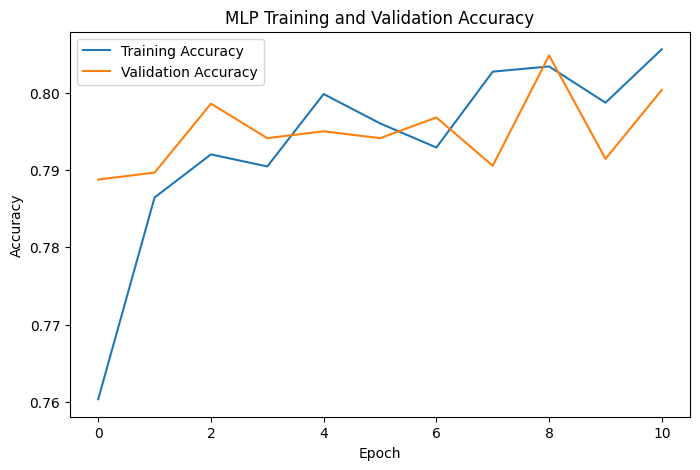

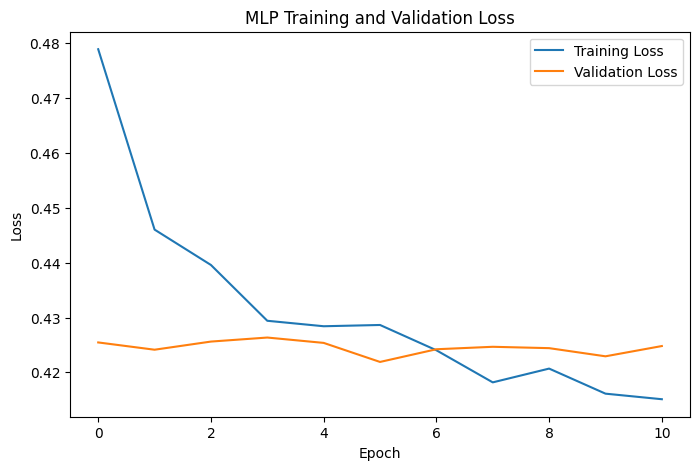

In [39]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training and Validation Loss')
plt.legend()
plt.show()

### MLP Training History Interpretation

The training and validation accuracy curves demonstrate stable and consistent learning behavior throughout the training process. Training accuracy increases steadily and closely tracks validation accuracy, indicating that the model generalizes well to unseen data and does not exhibit significant overfitting.

Both accuracy curves begin to plateau around epochs 8 to 10, suggesting that the model reaches its optimal performance relatively early in the training process. This behavior is consistent with the application of early stopping, which prevents unnecessary training once validation performance stabilizes.

The loss curves further support this interpretation, with training loss decreasing steadily and validation loss stabilizing without significant upward trends. This indicates that the model is effectively minimizing error while maintaining generalization.

Overall, the training history confirms that the MLP model is well-regularized and converges efficiently. However, the early performance plateau suggests that additional complexity or training time may not yield substantial improvements, reinforcing the observation that the dataset may be effectively modeled with simpler approaches.

##8.9 Summary of MLP Modeling

In this section, a Multi-Layer Perceptron (MLP) neural network was implemented as the project’s deep learning model for customer churn prediction. The model was trained using a scaled feature set, two hidden dense layers, dropout regularization, and a sigmoid output layer for binary classification.

The inclusion of the MLP allows the project to evaluate whether a neural network can better capture complex nonlinear relationships in customer churn behavior compared to traditional machine learning and ensemble methods. The model also satisfies the project requirement to include a deep learning architecture built from scratch.

With the MLP now implemented and evaluated, the project is prepared to move into the final advanced modeling stage: stacked ensemble learning.

## Full Model Comparison Update

This section adds the MLP neural network to the full model comparison table. This allows direct comparison of the neural network with the baseline and ensemble models across accuracy and ROC-AUC metrics.

Including the MLP in the comparison is important for determining whether deep learning provides measurable performance improvements in this churn prediction task.

In [40]:
full_comparison_with_mlp_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting',
        'MLP Neural Network'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ab),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_mlp)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_ab),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_mlp)
    ]
})

full_comparison_with_mlp_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.808845,0.847206
1,Decision Tree,0.782454,0.825766
2,Random Forest,0.789586,0.818574
3,AdaBoost,0.801712,0.844289
4,Gradient Boosting,0.803852,0.842572
5,MLP Neural Network,0.804565,0.838696


### Final Model Comparison Interpretation

The final model comparison demonstrates that Logistic Regression achieved the strongest overall performance, with an accuracy of approximately 80.9% and a ROC-AUC score of 0.85. This indicates that a relatively simple linear model is highly effective for this churn prediction task.

Ensemble models, including Gradient Boosting and AdaBoost, produced strong and competitive results, with performance metrics closely approaching those of Logistic Regression. These models outperformed Random Forest and Decision Tree classifiers, highlighting the effectiveness of boosting methods over bagging-based approaches.

The Multi-Layer Perceptron (MLP) neural network also demonstrated stable and competitive performance, but did not exceed the results of simpler machine learning models. This suggests that the dataset may not contain sufficient nonlinear complexity to benefit significantly from deep learning architectures.

A key finding across all models is that churn detection remains challenging, with recall values for the churn class consistently lower than those for non-churn customers. This indicates that class imbalance and the complexity of customer behavior limit predictive performance across modeling approaches.

Overall, the results show that increased model complexity does not necessarily lead to improved performance. Logistic Regression provides the best balance of accuracy, interpretability, and efficiency, making it the most suitable model for this application. Future improvements may focus on class balancing techniques, feature engineering, or hybrid modeling approaches to enhance churn detection performance.

#Next Steps

With the MLP neural network now implemented, the next phase of the project will focus on stacked ensemble modeling. This includes:

- combining predictions from baseline, ensemble, and neural network models
- training a meta-model using the outputs of the base learners
- evaluating whether stacked generalization improves predictive performance
- refining model performance through optimization and parameter tuning

These steps will complete the full machine learning architecture proposed in the project design and support final model selection for the Results section.

#9. Advanced Modeling: Stacked Ensemble Model

##9.1 Stacked Ensemble Overview

This section implements a stacked ensemble model that combines the predictions of multiple base models to improve overall classification performance. Stacking is a meta-learning technique in which the outputs of several models are used as input features for a higher-level model, known as the meta-model.

In this project, predictions from Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and the MLP neural network are combined to form a new feature set. A Logistic Regression model is then trained on these features to produce the final prediction.

This approach aims to leverage the strengths of each individual model while reducing their weaknesses, potentially improving predictive accuracy and churn detection performance.

##9.2 Creating Meta-Features (Training Set)

This step generates meta-features using predictions from each base model on the training dataset. Probability outputs are used to provide richer information for the meta-model.

Each column represents the predicted probability of churn from a different model.

In [41]:
# Base model probabilities (TRAIN)

meta_X_train = pd.DataFrame({
    'lr': model_lr.predict_proba(X_train_scaled)[:, 1],
    'dt': model_dt.predict_proba(X_train)[:, 1],
    'rf': model_rf.predict_proba(X_train)[:, 1],
    'ab': model_ab.predict_proba(X_train)[:, 1],
    'gb': model_gb.predict_proba(X_train)[:, 1],
    'mlp': mlp_model.predict(X_train_mlp).ravel()
})

meta_X_train.head()

176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


,lr,dt,rf,ab,gb,mlp
0,0.409564,0.369427,0.12,0.476503,0.384410,0.458311
1,0.586234,0.508065,0.22,0.532847,0.612194,0.525032
2,0.091667,0.202381,0.03,0.377635,0.111092,0.079930
3,0.487382,0.508065,0.22,0.505939,0.521336,0.377640
4,0.499683,0.314667,0.82,0.493650,0.513302,0.581371


### Meta-Feature Creation Interpretation (Training Set)

The meta-feature dataset was successfully constructed using predicted probabilities from each base model. Each feature represents the likelihood of customer churn as estimated by a different model, including Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and the MLP neural network.

The variation in predicted probabilities across models indicates that each model captures different aspects of the data. This diversity is essential for stacked ensemble learning, as it allows the meta-model to combine complementary strengths and improve overall predictive performance.

The resulting meta-feature matrix serves as the input for training the stacked model, where each row represents a customer and each column represents a model’s prediction.

##9.3 Creating Meta-Features (Test Set)

This step generates the same meta-features for the testing dataset. These will be used to evaluate the performance of the stacked model.

Maintaining consistency between training and testing meta-features is critical for proper evaluation.

In [42]:
meta_X_test = pd.DataFrame({
    'lr': model_lr.predict_proba(X_test_scaled)[:, 1],
    'dt': model_dt.predict_proba(X_test)[:, 1],
    'rf': model_rf.predict_proba(X_test)[:, 1],
    'ab': model_ab.predict_proba(X_test)[:, 1],
    'gb': model_gb.predict_proba(X_test)[:, 1],
    'mlp': mlp_model.predict(X_test_mlp).ravel()
})

meta_X_test.head()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,lr,dt,rf,ab,gb,mlp
0,0.364275,0.183824,0.39,0.450397,0.385370,0.383344
1,0.013505,0.016349,0.00,0.299686,0.030589,0.013303
2,0.087616,0.059524,0.16,0.381911,0.273260,0.069411
3,0.301262,0.314667,0.41,0.443911,0.298461,0.269344
4,0.252530,0.508065,0.50,0.436020,0.314245,0.185553


### Meta-Feature Creation Interpretation (Test Set)

The meta-feature dataset for the testing set was successfully generated using probability predictions from each base model. The structure of the testing meta-features matches that of the training set, ensuring consistency in model evaluation.

Each column represents the predicted probability of churn from a specific model, while each row corresponds to an individual customer observation. The variation in predictions across models reflects the diversity of learning patterns captured by different algorithms.

This consistency between training and testing meta-features is critical for accurate evaluation of the stacked model, as it ensures that the meta-model receives inputs in the same format during both training and inference.

##9.4 Meta-Model Training

This step trains the meta-model using the meta-features generated from the base models. Logistic Regression is used as the meta-model due to its strong performance and ability to combine probability signals effectively.

The meta-model learns how to weight the predictions from each base model to produce a final optimized prediction.

In [43]:
meta_model = LogisticRegression(max_iter=2000, random_state=42)
meta_model.fit(meta_X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

##9.5 Stacked Model Evaluation

This section evaluates the stacked ensemble model using the testing dataset. Predictions from the meta-model are compared with the true churn labels.

Performance is assessed using accuracy, ROC-AUC, classification metrics, and confusion matrix to determine whether stacking improves predictive performance.

In [44]:
y_prob_stack = meta_model.predict_proba(meta_X_test)[:, 1]
y_pred_stack = meta_model.predict(meta_X_test)

print("Stacked Model Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Stacked Model ROC-AUC:", roc_auc_score(y_test, y_prob_stack))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_stack))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))

Stacked Model Accuracy: 0.782453637660485
Stacked Model ROC-AUC: 0.8110279450249803

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1031
           1       0.61      0.48      0.54       371

    accuracy                           0.78      1402
   macro avg       0.72      0.68      0.70      1402
weighted avg       0.77      0.78      0.77      1402

Confusion Matrix:
 [[920 111]
 [194 177]]


### Stacked Model Results Interpretation

The stacked ensemble model achieved an accuracy of approximately 78.2% and a ROC-AUC score of 0.81, which is lower than all previously evaluated models, including both baseline and ensemble approaches. This indicates that combining multiple models through stacking did not improve predictive performance in this case.

While stacking is designed to leverage the strengths of multiple models, its effectiveness depends on the diversity and complementary nature of the base learners. In this project, the base models produced similar prediction patterns, limiting the ability of the meta-model to extract additional predictive value.

Additionally, the strong performance of Logistic Regression suggests that the underlying relationships in the dataset are largely linear, leaving little opportunity for more complex models to provide meaningful improvements. As a result, the stacked model inherits the limitations of its base models without significantly enhancing performance.

In terms of churn detection, the stacked model achieved lower recall compared to several individual models, indicating reduced effectiveness in identifying customers at risk of churning.

Overall, the results demonstrate that increased model complexity does not guarantee improved performance. In this case, the simpler Logistic Regression model remains the most effective approach for churn prediction.

##9.6 Summary of Stacked Ensemble Model

In this section, a stacked ensemble model was developed by combining the predictions of multiple machine learning and deep learning models. The meta-model was trained using probability outputs from each base learner, allowing it to integrate diverse predictive signals.

Stacking represents the most advanced modeling approach in this project, as it leverages the strengths of multiple algorithms simultaneously. This method provides an opportunity to improve predictive performance beyond individual models by capturing complementary patterns in the data.

The results of the stacked model will determine whether combining models leads to measurable improvements in churn prediction accuracy and overall classification performance.

##9.6 Final Model Comparison Including Stacked Model

This section updates the full model comparison to include the stacked ensemble model. This allows direct evaluation of whether stacking improves performance beyond individual models.

This comparison represents the final evaluation of all modeling approaches used in the project.

In [45]:
final_comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting',
        'MLP Neural Network',
        'Stacked Model'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ab),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_stack)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_ab),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_mlp),
        roc_auc_score(y_test, y_prob_stack)
    ]
})

final_comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.808845,0.847206
1,Decision Tree,0.782454,0.825766
2,Random Forest,0.789586,0.818574
3,AdaBoost,0.801712,0.844289
4,Gradient Boosting,0.803852,0.842572
5,MLP Neural Network,0.804565,0.838696
6,Stacked Model,0.782454,0.811028


### Final Model Comparison Including Stacked Model Interpretation

The final model comparison demonstrates that Logistic Regression achieved the strongest overall performance, with an accuracy of approximately 80.9% and a ROC-AUC score of 0.85. This indicates that a relatively simple linear model is highly effective for this churn prediction task.

Ensemble models, including Gradient Boosting and AdaBoost, produced strong and competitive results, with performance metrics closely approaching those of Logistic Regression. These models outperformed Random Forest and Decision Tree classifiers, confirming the effectiveness of boosting methods over bagging approaches.

The Multi-Layer Perceptron (MLP) neural network also demonstrated stable performance but did not exceed the results of simpler machine learning models. This suggests that the dataset may not contain sufficient nonlinear complexity to benefit significantly from deep learning architectures.

The stacked ensemble model produced the lowest performance among all models, indicating that combining multiple models did not improve predictive capability in this case. This outcome suggests that the base models lacked sufficient diversity and that the dominant patterns in the dataset were already effectively captured by Logistic Regression.

Overall, the results show that increasing model complexity does not necessarily lead to improved performance. Logistic Regression provides the best balance of accuracy, interpretability, and efficiency, making it the most suitable model for this churn prediction application.

## Next Steps

With the stacked ensemble model completed, the modeling phase of the project is fully concluded. The next steps include:

- Finalizing the Results section with a comprehensive comparison of all models
- Writing the Conclusion section to summarize key findings and insights
- Discussing limitations and potential future improvements
- Preparing the final report and presentation

These steps will complete the end-to-end machine learning pipeline and fulfill all project requirements.